7.710875114502849e-16
0.2672612419132214

Suggested next input (x_next): 0.986630-0.965119

Predicted output estimate: 0.005006317224846545


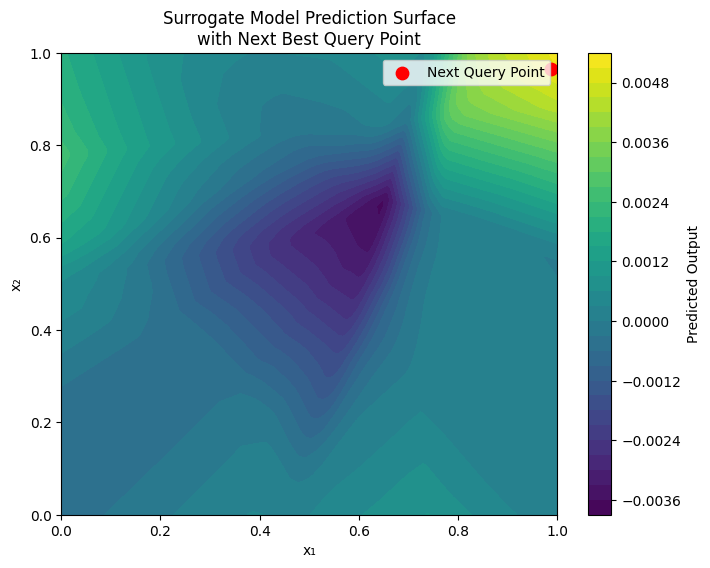

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from math import ceil, sqrt

def set_global_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Fix seeds for reproducibility
set_global_seeds(42)


# Make TensorFlow deterministic (optional, depends on hardware)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# ------------------------------------------------------------
# Load initial data
# ------------------------------------------------------------
X = np.load("initial_inputs.npy")        # shape (n0, d)
y = np.load("initial_outputs.npy")       # shape (n0,)

# ------------------------------------------------------------
# Append new information
# ------------------------------------------------------------
X = np.append(X,[[0.701438, 0.897524]], axis=0)  # Append week1 inputs
y = np.append(y, 4.907008577514035e-55)         # Append week1 outputs
X = np.append(X,[[0.605871, 0.208839]], axis=0)  # Append week2 inputs
y = np.append(y, -2.514581930414314e-56)         # Append week2 outputs
X = np.append(X,[[0.753513, 0.537998]], axis=0)  # Append week3 inputs
y = np.append(y, -1.415869936304869e-17)         # Append week3 outputs
X = np.append(X,[[0.611744, 0.846730]], axis=0)  # Append week4 inputs
y = np.append(y, -6.345928266392083e-34)         # Append week4 outputs
X = np.append(X,[[0.611593, 0.846560]], axis=0)  # Append week5 inputs
y = np.append(y, -7.012841886150039e-34)         # Append week5 outputs


# Define Neural Network surrogate model
class SurrogateNN(nn.Module):
    def __init__(self, input_dim):
        super(SurrogateNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

# Train Surrogate model with optional mini batching
def train_surrogate(X_train, y_train, input_dim, lr=0.01, epochs=300, batch_size=None):
    """
    Trains the neural network surrogate.
    If batch_size is None, uses full-batch training.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SurrogateNN(input_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    X_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)

    if batch_size is not None:
        dataset = TensorDataset(X_t, y_t)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    else:
        loader = [(X_t, y_t)]  # full-batch fallback

    for epoch in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = loss_fn(preds, yb)
            loss.backward()
            optimizer.step()

    return model

# Monte Carlo Sampling to Find Next Query Point
def suggest_next_query(model, input_dim, x_scaler, y_mean, y_std, n_candidates=10000):
    """
    Uses Monte Carlo sampling to suggest the next query point.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    # Generate random candidate points uniformly in [0,1]^d
    candidates = np.random.rand(n_candidates, input_dim)

    #Normalise candidates using fitted scaler
    candidates_norm = x_scaler.transform(candidates)

    # Predict for normalised candidates
    with torch.no_grad():
        preds_norm = model(torch.tensor(candidates_norm, dtype=torch.float32).to(device)).cpu().numpy()

    # Select candidate with highest predicted value
    best_idx = np.argmax(preds_norm)
    x_next_norm = candidates_norm[best_idx]
    y_pred_norm = preds_norm[best_idx]

    # Denormalise back to original scale
    x_next = x_scaler.inverse_transform(x_next_norm.reshape(1, -1)).flatten()
    y_pred = y_pred_norm * y_std + y_mean

    return x_next, y_pred

def visualize_surrogate_and_next_point(model, x_scaler, y_mean, y_std, x_next, resolution=200):
    """
    Visualises the surrogate model prediction surface and the chosen next point (x_next).
    Works only for 2D inputs.
    """

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    # Create a dense grid over [0,1] × [0,1]
    xx, yy = np.meshgrid(
        np.linspace(0, 1, resolution),
        np.linspace(0, 1, resolution)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]        # (resolution^2, 2)

    # Normalize grid
    grid_norm = x_scaler.transform(grid)

    # Predict
    with torch.no_grad():
        preds_norm = model(torch.tensor(grid_norm, dtype=torch.float32).to(device)).cpu().numpy()
    preds = preds_norm * y_std + y_mean         # denormalize prediction

    # Reshape to grid for contour plot
    Z = preds.reshape(xx.shape)

    # Plot
    plt.figure(figsize=(8, 6))
    contour = plt.contourf(xx, yy, Z, levels=30)
    plt.colorbar(contour, label="Predicted Output")

    # Mark the selected next point
    plt.scatter(x_next[0], x_next[1], c="red", s=80, label="Next Query Point")

    plt.xlabel("x₁")
    plt.ylabel("x₂")
    plt.title("Surrogate Model Prediction Surface\nwith Next Best Query Point")
    plt.legend()
    plt.show()


# ------------------------------------------------------------
# Normalise inputs and outputs
# ------------------------------------------------------------
x_scaler = StandardScaler()
Xn = x_scaler.fit_transform(X)

y_mean = y.mean()
y_std = y.std() if y.std() > 0 else 1.0
yn = (y - y_mean) / y_std                 # Model works better with normalized target


batch_size = 8   # number or None
print(max(y))
print(max(yn))

# Calcualte input shape
input_dim = Xn.shape[1]

model = train_surrogate(Xn, yn, input_dim, lr=0.01, epochs=500, batch_size=batch_size)

x_next, y_pred = suggest_next_query(model, input_dim, x_scaler, y_mean, y_std, n_candidates=5000)
x_next = np.clip(x_next, 0, 1)

next_query = "-".join([f"{xi:.6f}" for xi in x_next])
print("\nSuggested next input (x_next):", next_query)

print("\nPredicted output estimate:", float(y_pred[0]))

visualize_surrogate_and_next_point(model, x_scaler, y_mean, y_std, x_next)
    